In [1]:
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

In [2]:
import sys
sys.path.append("/home/izirdeli/Documents.cglab/DownStreamAnalysis/03.Code")
from plotting_functions import custom_plots
plt.rcParams.update(custom_plots())

## data

In [3]:
data = pd.read_csv("../../Model/Data_Preparation/processed/m2or_pairs_model.csv", sep=",")
data

,Species,UniProt ID,Sequence,SMILES,Mixture,Responsive,seq_id,smiles_id,mutation,Class
0,homo sapiens,Q8NGN2,MTSRSVCEKMTMTTENPNQTVVSHFFLEGLRYTAKHSSLFFLLFLL...,CC1=CC[C@H](CC1)C(=C)C,mono,0,SEQ0000,SML0000,False,class 2
1,homo sapiens,Q8NGN2,MTSRSVCEKMTMTTENPNQTVVSHFFLEGLRYTAKHSSLFFLLFLL...,CC1=CC[C@@H](CC1=O)C(=C)C,mono,0,SEQ0000,SML0001,False,class 2
2,homo sapiens,Q8NGN2,MTSRSVCEKMTMTTENPNQTVVSHFFLEGLRYTAKHSSLFFLLFLL...,C[C@H]1CC[C@@H]([C@H](C1)O)C(C)C,mono,0,SEQ0000,SML0002,False,class 2
3,homo sapiens,Q8NGN2,MTSRSVCEKMTMTTENPNQTVVSHFFLEGLRYTAKHSSLFFLLFLL...,CCCCO,mono,0,SEQ0000,SML0003,False,class 2
4,homo sapiens,Q8NGN2,MTSRSVCEKMTMTTENPNQTVVSHFFLEGLRYTAKHSSLFFLLFLL...,CCCCOCC(C)O,sum of isomers,0,SEQ0000,SML0004,False,class 2
...,...,...,...,...,...,...,...,...,...,...
52170,homo sapiens,A6NGY5,MLQNQDTMEILSNSTSKFPTFLLTGIPGLESAHVWISIPFCCFYAI...,CCCCCC=O,mono,0,SEQ0523,SML0163,False,class 1
52171,homo sapiens,Q8NGJ9,MAIFNNTTSSSSNFLLTAFPGLECAHVWISIPVCCLYTIALLGNSM...,CCCCCC=O,mono,0,SEQ0952,SML0163,False,class 1
52172,homo sapiens,Q8NH55,MLHTNNTQFHPSTFLVVGVPGLEDVHVWIGFPFFAVYLTALLGNII...,CCCCCC=O,mono,0,SEQ0955,SML0163,False,class 1
52173,homo sapiens,Q8NGH7,MTLVSFFSFLSKPLIMLLSNSSWRLSQPSFLLVGIPGLEESQHWIA...,CCCCCC=O,mono,0,SEQ0957,SML0163,False,class 1


In [4]:
PREDICTION_THRESHOLD = 0.915

probabilities = pd.read_csv("../../Downstream_Analysis/predictions/aggregated/ASR_Predictions/asr_median_probability_wide.csv")
ligand_columns = [column for column in probabilities.columns if column.startswith("SML")]

predictions = probabilities.copy()
predictions[ligand_columns] = (probabilities[ligand_columns] > PREDICTION_THRESHOLD).astype(int)
predictions

,protein_id,SML0000,SML0001,SML0002,SML0003,SML0004,SML0005,SML0006,SML0007,SML0008,...,SML0744,SML0745,SML0746,SML0747,SML0748,SML0749,SML0750,SML0768,SML0769,SML0770
0,node_100_ASR,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1,node_101_ASR,0,0,0,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0
2,node_102_ASR,0,0,0,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0
3,node_103_ASR,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,node_104_ASR,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
427,node_96_ASR,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
428,node_97_ASR,0,0,0,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0
429,node_98_ASR,0,0,0,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0
430,node_99_ASR,0,0,0,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0


### mapping

In [5]:
smiles_map = (
    data[["smiles_id", "SMILES"]]
    .drop_duplicates()
    .rename(columns={"smiles_id": "SML_ID"})
)

In [6]:
smiles_map

,SML_ID,SMILES
0,SML0000,CC1=CC[C@H](CC1)C(=C)C
1,SML0001,CC1=CC[C@@H](CC1=O)C(=C)C
2,SML0002,C[C@H]1CC[C@@H]([C@H](C1)O)C(C)C
3,SML0003,CCCCO
4,SML0004,CCCCOCC(C)O
...,...,...
48316,SML0749,CCOC(=O)C(C)S
49585,SML0750,CC(=O)C1=CC2=CC=CC=C2C=C1
50146,SML0768,C[C@H]1CCC[C@@]2([C@@]1(CCCC2)O)C
50251,SML0769,C=CCSS(=O)CC=C


In [7]:
nodes_of_interest = ["node_1_ASR", "node_2_ASR", "node_3_ASR"]

pred_sub = predictions[predictions["protein_id"].isin(nodes_of_interest)].copy()
pred_sub

,protein_id,SML0000,SML0001,SML0002,SML0003,SML0004,SML0005,SML0006,SML0007,SML0008,...,SML0744,SML0745,SML0746,SML0747,SML0748,SML0749,SML0750,SML0768,SML0769,SML0770
110,node_1_ASR,0,0,0,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0
221,node_2_ASR,0,0,0,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,0,0
332,node_3_ASR,0,0,0,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0


In [8]:
sml_cols = [c for c in pred_sub.columns if c != "protein_id"]

# long format
pred_long = pred_sub.melt(
    id_vars="protein_id",
    value_vars=sml_cols,
    var_name="SML_ID",
    value_name="active"
)

pred_long

,protein_id,SML_ID,active
0,node_1_ASR,SML0000,0
1,node_2_ASR,SML0000,0
2,node_3_ASR,SML0000,0
3,node_1_ASR,SML0001,0
4,node_2_ASR,SML0001,0
...,...,...,...
2257,node_2_ASR,SML0769,0
2258,node_3_ASR,SML0769,0
2259,node_1_ASR,SML0770,0
2260,node_2_ASR,SML0770,0


In [9]:
pred_active = pred_long[pred_long["active"] == 1].copy()
pred_active = pred_active.merge(smiles_map, on="SML_ID", how="left")

pred_active

,protein_id,SML_ID,active,SMILES
0,node_1_ASR,SML0012,1,CC1=CCC2CC1C2(C)C
1,node_3_ASR,SML0012,1,CC1=CCC2CC1C2(C)C
2,node_1_ASR,SML0014,1,CC1(C2CCC(=C)C1C2)C
3,node_2_ASR,SML0015,1,CC(=O)O
4,node_2_ASR,SML0016,1,CCCC(=O)O
...,...,...,...,...
415,node_1_ASR,SML0746,1,CCC(C)C1=C(C=CC=N1)OC
416,node_3_ASR,SML0746,1,CCC(C)C1=C(C=CC=N1)OC
417,node_1_ASR,SML0747,1,CC(C)CC1=C(C=CC=N1)OC
418,node_3_ASR,SML0747,1,CC(C)CC1=C(C=CC=N1)OC


In [10]:
node_counts = (
    pred_active.groupby("protein_id")["SMILES"]
    .nunique()
    .reset_index(name="n_unique_ligands")
)

node_counts

,protein_id,n_unique_ligands
0,node_1_ASR,177
1,node_2_ASR,130
2,node_3_ASR,113


In [11]:
node_ligands = (
    pred_active.groupby("protein_id")["SMILES"]
    .apply(list)
    .to_dict()
)

for node, ligs in node_ligands.items():
    print(f"\n{node}: {len(ligs)} ligands")
    print(ligs)


node_1_ASR: 177 ligands
['CC1=CCC2CC1C2(C)C', 'CC1(C2CCC(=C)C1C2)C', 'C1=CC=C2C(=C1)C=CC(=O)O2', 'CC(=CCC/C(=C/CC/C(=C/CO)/C)/C)C', 'CC(=CCC/C(=C/CO)/C)C', 'CC(CC1=CC=C(C=C1)C(C)(C)C)C=O', 'CC(=O)NCCC1=CNC2=C1C=C(C=C2)OC', 'CC1CCC2=NC=CN=C12', 'CC(=O)C1=NC=CN=C1', 'CCC(C)C1=NC=CN=C1OC', 'CC(CC=O)C1=CC=CC=C1', 'CC(=CCC/C(=C\\CO)/C)C', 'CCCCCOC(=O)C', 'C1CCC(=O)CC1', 'CC(=O)C1=CC=CC=C1', 'CC1C(=NC(S1)C)C', 'C[C@@H]1CC[C@H]([C@@H](C1)O)C(C)C', 'CCCCCCC/C=C/C=O', 'C[C@]12CC[C@H]3[C@H]([C@@H]1CC=C2)CC[C@@H]4[C@@]3(CCC(=O)C4)C', 'CCCCOC(=O)C', 'C1CCCCCC(=O)OCCOC(=O)CCCCC1', 'CC(=O)OC1=C(C=C(C=C1)CC=C)OC', 'C[C@]12CC[C@H]3[C@H]([C@@H]1CC=C2)CCC4=CC(=O)CC[C@]34C', 'CC(=CCC/C(=C/COC(=O)C)/C)C', 'CC(=O)O[C@H]1C[C@H]2CC[C@]1(C2(C)C)C', 'C/C=C/C1=CC(=C(C=C1)O)OC', 'C1=CC=C(C=C1)CC=O', 'COC(=O)C1=CC=CC=C1', 'CC1=C(C=C(C=C1)[N+](=O)[O-])[N+](=O)[O-]', 'CC1COCC2=CC3=C(C=C12)C(C(C3(C)C)C)(C)C', 'CC(C)C1=NC=CN=C1OC', 'CC(C)CC1=NC=CN=C1OC', 'CCCCCC/C=C/C=O', 'C[C@@H]1CC(=O)C=C2[C@]1(C[C@@H](CC2)C(=C)C)

### dataframe node_presence

In [12]:
node_presence = (
    pred_active.assign(active=1)
    .pivot_table(
        index="SMILES",
        columns="protein_id",
        values="active",
        aggfunc="max",
        fill_value=0
    )
    .reset_index()
)

node_presence = node_presence.rename(columns={
    "node_1_ASR": "common_ancestor",
    "node_2_ASR": "class1_ancestor",
    "node_3_ASR": "class2_ancestor"
})

node_presence

protein_id,SMILES,common_ancestor,class1_ancestor,class2_ancestor
0,C(C(=O)C(=O)O)O,0,1,0
1,C(C(=O)O)N,0,1,0
2,C(C(=O)O)S,0,1,0
3,C(C(C(=O)O)N)N,0,1,0
4,C(C(C=O)O)O,0,1,0
...,...,...,...,...
261,C[C@]12CC[C@H]3[C@H]([C@@H]1CCC2=O)CCC4=CC(=O)...,1,1,1
262,C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@@H]2O)CCC4=CC...,1,1,1
263,C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@@H]2O)CCC4=CC...,1,1,1
264,C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@H]2O)CCC4=CC(...,1,1,1


### evolutionary sets

In [13]:
### evolutionary sets ###

common_set = set(node_presence.loc[node_presence["common_ancestor"] == 1, "SMILES"])
class1_set = set(node_presence.loc[node_presence["class1_ancestor"] == 1, "SMILES"])
class2_set = set(node_presence.loc[node_presence["class2_ancestor"] == 1, "SMILES"])

shared_all = common_set & class1_set & class2_set

class1_gains = class1_set - common_set
class2_gains = class2_set - common_set

class1_losses = common_set - class1_set
class2_losses = common_set - class2_set

print("Common ancestor ligands:", len(common_set))
print("Class 1 ancestor ligands:", len(class1_set))
print("Class 2 ancestor ligands:", len(class2_set))
print("Shared by all three:", len(shared_all))
print("Class 1 gains:", len(class1_gains))
print("Class 2 gains:", len(class2_gains))
print("Class 1 losses:", len(class1_losses))
print("Class 2 losses:", len(class2_losses))

Common ancestor ligands: 177
Class 1 ancestor ligands: 130
Class 2 ancestor ligands: 113
Shared by all three: 27
Class 1 gains: 89
Class 2 gains: 0
Class 1 losses: 136
Class 2 losses: 64


### activation pattern

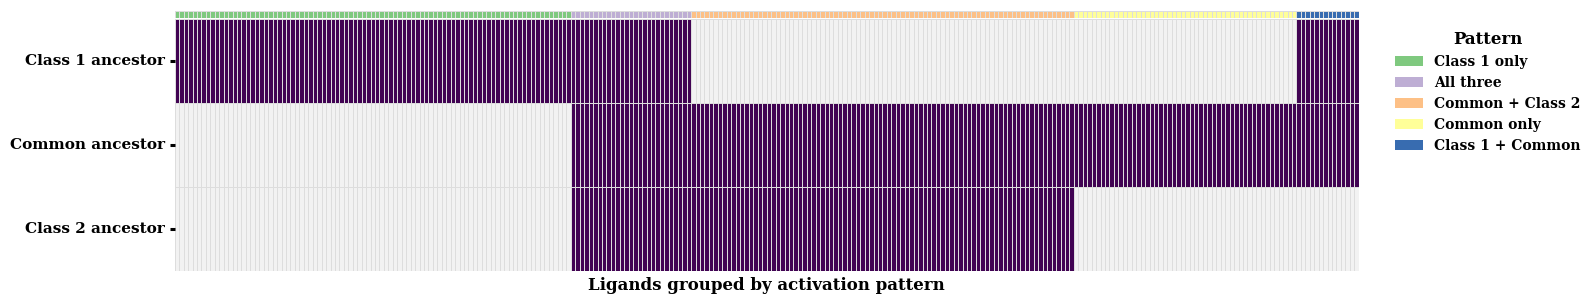

In [14]:
# build matrix from node_presence
X = (
    node_presence.set_index("SMILES")[["class1_ancestor", "common_ancestor", "class2_ancestor"]]
    .T
)

# rename rows for display
X.index = ["Class 1 ancestor", "Common ancestor", "Class 2 ancestor"]

# keep only ligands active in at least one node
X = X.loc[:, X.sum(axis=0) > 0]

# pattern per ligand (column), based on row order above
patterns = X.apply(lambda col: "".join(col.astype(int).astype(str).values), axis=0).astype(str)

# readable order
pat_order = ["100", "111", "011", "010", "110"]

# sort columns by pattern
col_order = sorted(X.columns, key=lambda c: pat_order.index(patterns.loc[c]))
Xo = X[col_order]

# color strip for column patterns
pat_palette = dict(zip(pat_order, sns.color_palette("Accent", n_colors=len(pat_order))))
col_colors = patterns.loc[col_order].map(pat_palette).tolist()

# binary heatmap colors
bin_cmap = ListedColormap(["#f2f2f2", "#410353"])

cg = sns.clustermap(
    Xo,
    row_cluster=False,
    col_cluster=False,
    cmap=bin_cmap,
    vmin=0, vmax=1,
    cbar_pos=None,
    xticklabels=False,
    yticklabels=True,
    col_colors=col_colors,
    linewidths=0.4,
    linecolor="#dddddd",
    figsize=(14, 3.2),
    dendrogram_ratio=(0.001, 0.001),
    colors_ratio=(0.03, 0.03)
)

# format heatmap axis
ax = cg.ax_heatmap
ax.set_yticklabels(ax.get_ymajorticklabels(), rotation=0, fontsize=11)
ax.yaxis.tick_left()
ax.tick_params(axis='y', left=True, right=False, labelleft=True, labelright=False)
ax.set_xlabel("Ligands grouped by activation pattern", fontsize=12)
ax.set_ylabel("")

pattern_labels = {
    "100": "Class 1 only",
    "111": "All three",
    "011": "Common + Class 2",
    "010": "Common only",
    "110": "Class 1 + Common"
}

handles = [
    Patch(facecolor=pat_palette[p], edgecolor='none', label=pattern_labels[p])
    for p in pat_order
]


ax.legend(
    handles=handles,
    title="Pattern",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)
plt.savefig("logp_transitions_human_ancestors_heatmap.svg", bbox_inches="tight", transparent=True, dpi=300)
plt.show()

In [15]:
pattern_df = pd.DataFrame({
    "SMILES": X.columns,
    "pattern": patterns.loc[X.columns].values
})

pattern_df

,SMILES,pattern
0,C(C(=O)C(=O)O)O,100
1,C(C(=O)O)N,100
2,C(C(=O)O)S,100
3,C(C(C(=O)O)N)N,100
4,C(C(C=O)O)O,100
...,...,...
261,C[C@]12CC[C@H]3[C@H]([C@@H]1CCC2=O)CCC4=CC(=O)...,111
262,C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@@H]2O)CCC4=CC...,111
263,C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@@H]2O)CCC4=CC...,111
264,C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@H]2O)CCC4=CC(...,111


In [16]:
pattern_sets = {
    pat: set(pattern_df.loc[pattern_df["pattern"] == pat, "SMILES"])
    for pat in ["100", "111", "011", "010", "110"]
}

class1_side_a_e = pattern_sets["100"] | pattern_sets["110"]
class2_side_c = pattern_sets["011"]
shared_code_b = pattern_sets["111"]
common_ancestor_only_d = pattern_sets["010"]

code_sets = {
    "class1_side_a_e": class1_side_a_e,
    "class2_side_c": class2_side_c,
    "shared_code_b": shared_code_b,
    "common_ancestor_only_d": common_ancestor_only_d,
}

for code, ligs in code_sets.items():
    print(f"{code}: {len(ligs)} ligands")

class1_side_a_e: 103 ligands
class2_side_c: 86 ligands
shared_code_b: 27 ligands
common_ancestor_only_d: 50 ligands


## Evolutionary sets analysis

In [17]:
def label_set(smiles_set, label):
    return pd.DataFrame({"SMILES": list(smiles_set), "group": label})

compare_df = pd.concat([
    label_set(common_set, "common_ancestor"),
    label_set(class1_set, "class1_ancestor"),
    label_set(class2_set, "class2_ancestor"),
    label_set(class1_gains, "class1_gains"),
    label_set(class1_losses, "class1_losses"),
    label_set(class2_losses, "class2_losses"),
], ignore_index=True)

compare_df

,SMILES,group
0,CC(CC1=CC=CC=C1)C=O,common_ancestor
1,CC(=C)[C@@H]1CCC(=CC1)C=O,common_ancestor
2,CC1=C(C=CO1)SSC,common_ancestor
3,CC(=C)C(=O)O[C@H]1C[C@]23[C@H](O2)CC/C(=C/[C@@...,common_ancestor
4,C1=COC(=C1)CSCC2=CC=CO2,common_ancestor
...,...,...
704,CC(C)C1C(COC(O1)(C)C)(C)C,class2_losses
705,CC(CN)C1=CC=CC=C1,class2_losses
706,CC(=CCC/C(=C/C(OC)OC)/C)C,class2_losses
707,CCCC/C=C/C=C/C=O,class2_losses


In [18]:
compare_df.value_counts("group")

group
common_ancestor    177
class1_losses      136
class1_ancestor    130
class2_ancestor    113
class1_gains        89
class2_losses       64
Name: count, dtype: int64

In [19]:
all_smiles = sorted(set(compare_df["SMILES"]))
print(len(all_smiles))


desc_rows = []
for smi in all_smiles:
    mol = Chem.MolFromSmiles(smi)
    
    if mol is None:
        desc_rows.append({
            "SMILES": smi,
            "logP": np.nan,
            "TPSA": np.nan,
            "MW": np.nan,
            "HBD": np.nan,
            "HBA": np.nan
        })
    else:
        desc_rows.append({
            "SMILES": smi,
            "logP": Descriptors.MolLogP(mol),
            "TPSA": rdMolDescriptors.CalcTPSA(mol),
            "MW": Descriptors.MolWt(mol),
            "HBD": rdMolDescriptors.CalcNumHBD(mol),
            "HBA": rdMolDescriptors.CalcNumHBA(mol)
        })

desc_df = pd.DataFrame(desc_rows)

compare_df = compare_df.merge(desc_df, on="SMILES", how="left")
compare_df

266


,SMILES,group,logP,TPSA,MW,HBD,HBA
0,CC(CC1=CC=CC=C1)C=O,common_ancestor,2.06410,17.07,148.205,0,1
1,CC(=C)[C@@H]1CCC(=CC1)C=O,common_ancestor,2.48790,17.07,150.221,0,1
2,CC1=C(C=CO1)SSC,common_ancestor,2.95812,13.14,160.263,0,3
3,CC(=C)C(=O)O[C@H]1C[C@]23[C@H](O2)CC/C(=C/[C@@...,common_ancestor,1.16860,94.59,362.378,1,7
4,C1=COC(=C1)CSCC2=CC=CO2,common_ancestor,3.30600,26.28,194.255,0,3
...,...,...,...,...,...,...,...
704,CC(C)C1C(COC(O1)(C)C)(C)C,class2_losses,2.82010,18.46,186.295,0,2
705,CC(CN)C1=CC=CC=C1,class2_losses,1.74880,26.02,135.210,1,1
706,CC(=CCC/C(=C/C(OC)OC)/C)C,class2_losses,3.29800,18.46,198.306,0,2
707,CCCC/C=C/C=C/C=O,class2_losses,2.48790,17.07,138.210,0,1


In [20]:
fg_smarts = {
    "carboxylic_acid": "[CX3](=O)[OX2H1]",
    "alcohol": "[OX2H][CX4;!$(C=O)]",
    "aldehyde": "[CX3H1](=O)[#6]",
    "ketone": "[#6][CX3](=O)[#6]",
    "ester": "[CX3](=O)[OX2][#6]",
    "ether": "[OD2]([#6])[#6]",
    "amine": "[NX3;H2,H1,H0;!$(NC=O)]",
    "amide": "[NX3][CX3](=O)[#6]",
    "aromatic_ring": "a1aaaaa1",
    "phenol": "c[OX2H]",
    "nitrile": "[CX2]#N",
    "alkene": "[CX3]=[CX3]"
}

fg_patterns = {name: Chem.MolFromSmarts(smarts) for name, smarts in fg_smarts.items()}

# parse molecules once
mol_map = {smi: Chem.MolFromSmiles(smi) for smi in all_smiles}

fg_rows = []
for smi in all_smiles:
    mol = mol_map[smi]
    row = {"SMILES": smi}
    for fg_name, patt in fg_patterns.items():
        row[fg_name] = int(mol.HasSubstructMatch(patt)) if mol is not None else np.nan
    fg_rows.append(row)

fg_df = pd.DataFrame(fg_rows)

compare_df = compare_df.merge(fg_df, on="SMILES", how="left")
compare_df

,SMILES,group,logP,TPSA,MW,HBD,HBA,carboxylic_acid,alcohol,aldehyde,ketone,ester,ether,amine,amide,aromatic_ring,phenol,nitrile,alkene
0,CC(CC1=CC=CC=C1)C=O,common_ancestor,2.06410,17.07,148.205,0,1,0,0,1,0,0,0,0,0,1,0,0,0
1,CC(=C)[C@@H]1CCC(=CC1)C=O,common_ancestor,2.48790,17.07,150.221,0,1,0,0,1,0,0,0,0,0,0,0,0,1
2,CC1=C(C=CO1)SSC,common_ancestor,2.95812,13.14,160.263,0,3,0,0,0,0,0,0,0,0,0,0,0,0
3,CC(=C)C(=O)O[C@H]1C[C@]23[C@H](O2)CC/C(=C/[C@@...,common_ancestor,1.16860,94.59,362.378,1,7,0,1,0,0,1,1,0,0,0,0,0,1
4,C1=COC(=C1)CSCC2=CC=CO2,common_ancestor,3.30600,26.28,194.255,0,3,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
704,CC(C)C1C(COC(O1)(C)C)(C)C,class2_losses,2.82010,18.46,186.295,0,2,0,0,0,0,0,1,0,0,0,0,0,0
705,CC(CN)C1=CC=CC=C1,class2_losses,1.74880,26.02,135.210,1,1,0,0,0,0,0,0,1,0,1,0,0,0
706,CC(=CCC/C(=C/C(OC)OC)/C)C,class2_losses,3.29800,18.46,198.306,0,2,0,0,0,0,0,1,0,0,0,0,0,1
707,CCCC/C=C/C=C/C=O,class2_losses,2.48790,17.07,138.210,0,1,0,0,1,0,0,0,0,0,0,0,0,1


### 3 groups

In [21]:
compare_df["group"].value_counts()

group
common_ancestor    177
class1_losses      136
class1_ancestor    130
class2_ancestor    113
class1_gains        89
class2_losses       64
Name: count, dtype: int64

In [22]:
compare3_df = compare_df[
    compare_df["group"].isin(["common_ancestor", "class1_ancestor", "class2_ancestor"])
].copy()

compare3_df["group"].value_counts()

group
common_ancestor    177
class1_ancestor    130
class2_ancestor    113
Name: count, dtype: int64

In [23]:
target_sets = {
    "common_ancestor": set(compare3_df.loc[compare3_df["group"] == "common_ancestor", "SMILES"]) - shared_code_b,
    "class1_ancestor": class1_side_a_e,
    "class2_ancestor": class2_side_c
}

plot_order = ["common_ancestor", "class1_ancestor", "class2_ancestor"]

# Now, extract the logP values using these specific SMILES sets
data_to_plot = []
for g in plot_order:
    relevant_smiles = target_sets[g]
    # Filter the main dataframe for these specific molecules
    vals = compare3_df.loc[compare3_df["SMILES"].isin(relevant_smiles), "logP"].dropna().values
    data_to_plot.append(vals)
    print(f"{g}: {len(vals)} ligands")

common_ancestor: 250 ligands
class1_ancestor: 117 ligands
class2_ancestor: 172 ligands


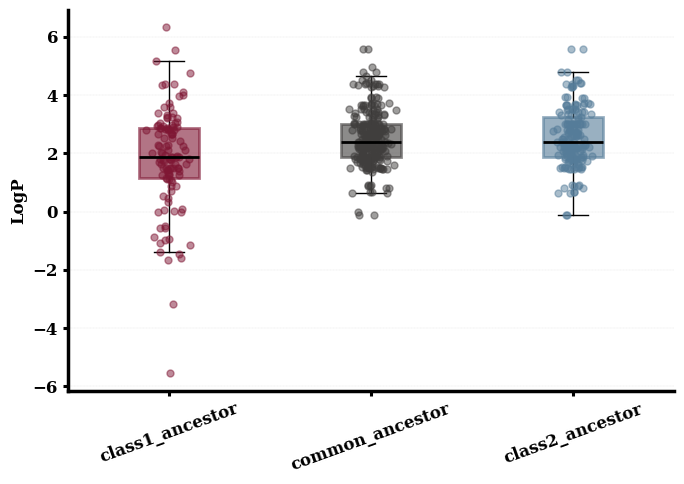

In [31]:
target_sets = {
    "common_ancestor": set(compare3_df.loc[compare3_df["group"] == "common_ancestor", "SMILES"]) - shared_code_b,
    "class1_ancestor": class1_side_a_e,
    "class2_ancestor": class2_side_c
}

plot_order = ["class1_ancestor", "common_ancestor", "class2_ancestor"]
colors = ["#7f1734ff", "#403e3dff", "#557c99ff"] 

data_to_plot = []
for g in plot_order:
    relevant_smiles = target_sets[g]
    vals = compare3_df.loc[compare3_df["SMILES"].isin(relevant_smiles), "logP"].dropna().values
    data_to_plot.append(vals)

plt.figure(figsize=(7,5))

bplot = plt.boxplot(data_to_plot, tick_labels=plot_order, 
                    showfliers=False, patch_artist=True)

for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
    patch.set_edgecolor(color)
    patch.set_linewidth(2)

for median in bplot['medians']:
    median.set_color('black')
    median.set_linewidth(2)

for i, (g, color) in enumerate(zip(plot_order, colors), start=1):
    relevant_smiles = target_sets[g]
    y = compare3_df.loc[compare3_df["SMILES"].isin(relevant_smiles), "logP"].dropna().values
    x = np.random.normal(i, 0.04, size=len(y))
    plt.plot(x, y, "o", color=color, alpha=0.5, markersize=5)

plt.gca().set_axisbelow(True)                                    # grid behind boxes
plt.grid(axis="y", linestyle="--", alpha=0.2)


plt.ylabel("LogP")
#plt.title("Lipophilicity across ancestral ligand sets")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("lipophilicity_ancestral_sets.png", bbox_inches="tight", transparent=True, dpi=300)
plt.show()

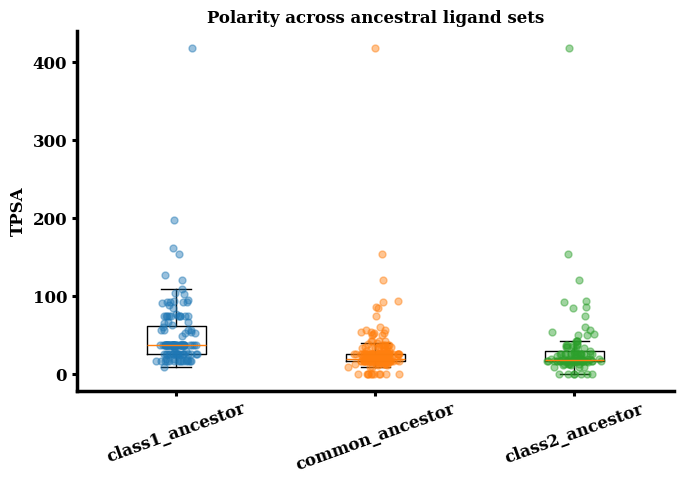

In [25]:
plt.figure(figsize=(7,5))

data_to_plot = [
    compare3_df.loc[compare3_df["group"] == g, "TPSA"].dropna().values
    for g in plot_order
]

plt.boxplot(data_to_plot, tick_labels=plot_order, showfliers=False)

for i, g in enumerate(plot_order, start=1):
    y = compare3_df.loc[compare3_df["group"] == g, "TPSA"].dropna().values
    x = np.random.normal(i, 0.05, size=len(y))
    plt.plot(x, y, "o", alpha=0.45)

plt.ylabel("TPSA")
plt.title("Polarity across ancestral ligand sets")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

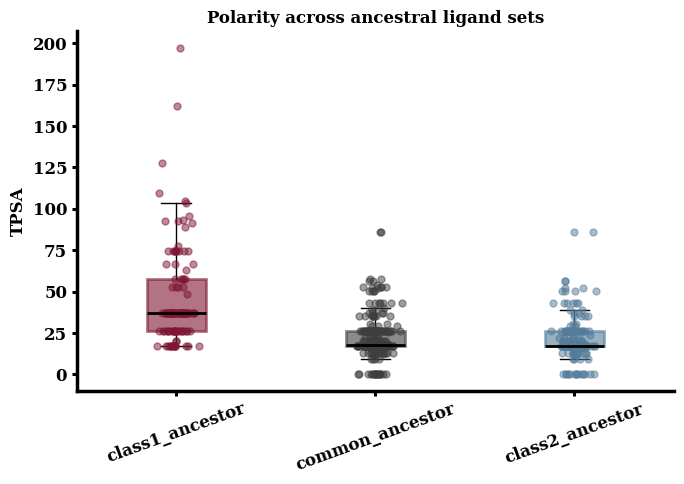

In [27]:
plot_order = ["class1_ancestor", "common_ancestor", "class2_ancestor"]
colors = ["#7f1734ff", "#403e3dff", "#557c99ff"] 

plt.figure(figsize=(7,5))

data_to_plot = []
for g in plot_order:
    relevant_smiles = target_sets[g]
    vals = compare3_df.loc[compare3_df["SMILES"].isin(relevant_smiles), "TPSA"].dropna().values
    data_to_plot.append(vals)

bplot = plt.boxplot(data_to_plot, tick_labels=plot_order, 
                    showfliers=False, patch_artist=True)

for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
    patch.set_edgecolor(color)
    patch.set_linewidth(2)

for median in bplot['medians']:
    median.set_color('black')
    median.set_linewidth(2)

for i, (g, color) in enumerate(zip(plot_order, colors), start=1):
    relevant_smiles = target_sets[g]
    y = compare3_df.loc[compare3_df["SMILES"].isin(relevant_smiles), "TPSA"].dropna().values
    x = np.random.normal(i, 0.04, size=len(y))
    plt.plot(x, y, "o", color=color, alpha=0.5, markersize=5)

plt.ylabel("TPSA")
plt.title("Polarity across ancestral ligand sets")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

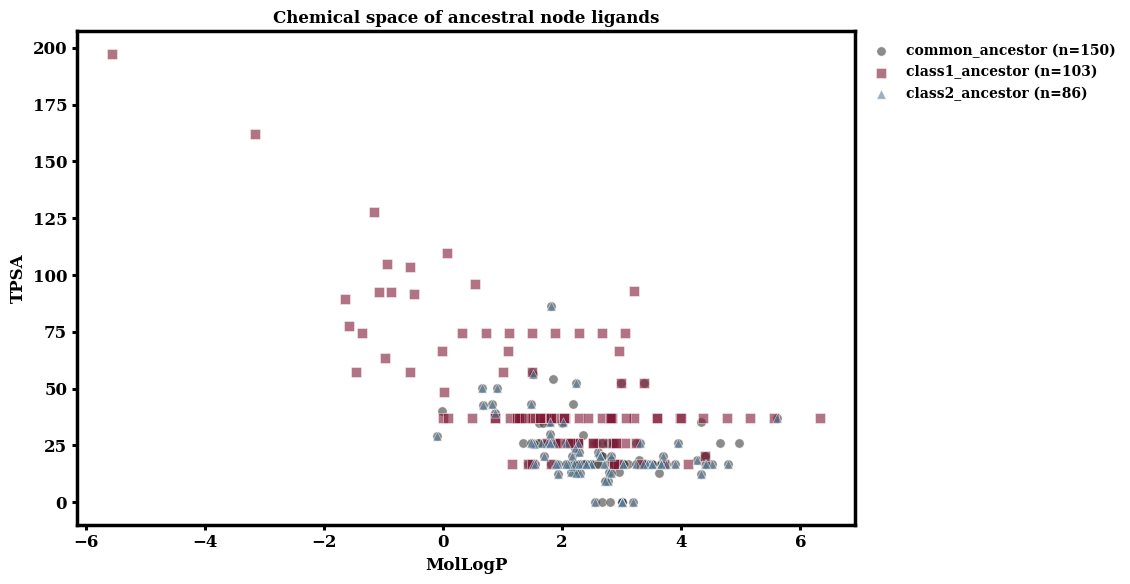

In [ ]:
plot_order = ["common_ancestor", "class1_ancestor", "class2_ancestor"]
colors = ["#403e3dff", "#7f1734ff", "#557c99ff"] 

marker_map = {
    "common_ancestor": "o",
    "class1_ancestor": "s",
    "class2_ancestor": "^"
}

plt.figure(figsize=(12,6))

for g, color in zip(plot_order, colors):
    relevant_smiles = target_sets[g]
    sub = compare3_df[compare3_df["SMILES"].isin(relevant_smiles)]
    
    plt.scatter(
        sub["logP"],
        sub["TPSA"],
        alpha=0.6,
        color=color,          
        label=f"{g} (n={len(sub)})", 
        marker=marker_map[g],
        edgecolors='white',   
        linewidths=0.5,
        s=45                  
    )

plt.xlabel("MolLogP")
plt.ylabel("TPSA")
plt.title("Chemical space of ancestral node ligands")

plt.legend(frameon=False, loc='upper right', bbox_to_anchor=(1.35, 1.0))
plt.tight_layout()
plt.show()

In [28]:
import pandas as pd

fg_cols = [
    "carboxylic_acid", "alcohol", "aldehyde", "ketone", "ester",
    "ether", "amine", "amide", "aromatic_ring", "phenol",
    "nitrile", "alkene"
]

fg_cols_valid = [col for col in fg_cols if col in compare3_df.columns]

prevalence_data = {}

for g in plot_order:
    relevant_smiles = target_sets[g]
    
    sub = compare3_df[compare3_df["SMILES"].isin(relevant_smiles)]
    
    prevalence_data[g] = sub[fg_cols_valid].mean()

fg_prevalence_3 = pd.DataFrame(prevalence_data)

fg_prevalence_3

,class1_ancestor,common_ancestor,class2_ancestor
carboxylic_acid,0.615385,0.024,0.011628
alcohol,0.076923,0.060,0.058140
aldehyde,0.136752,0.180,0.162791
ketone,0.025641,0.224,0.302326
ester,0.213675,0.208,0.116279
ether,0.264957,0.324,0.232558
amine,0.042735,0.036,0.046512
amide,0.042735,0.016,0.011628
aromatic_ring,0.170940,0.500,0.523256
phenol,0.051282,0.036,0.034884


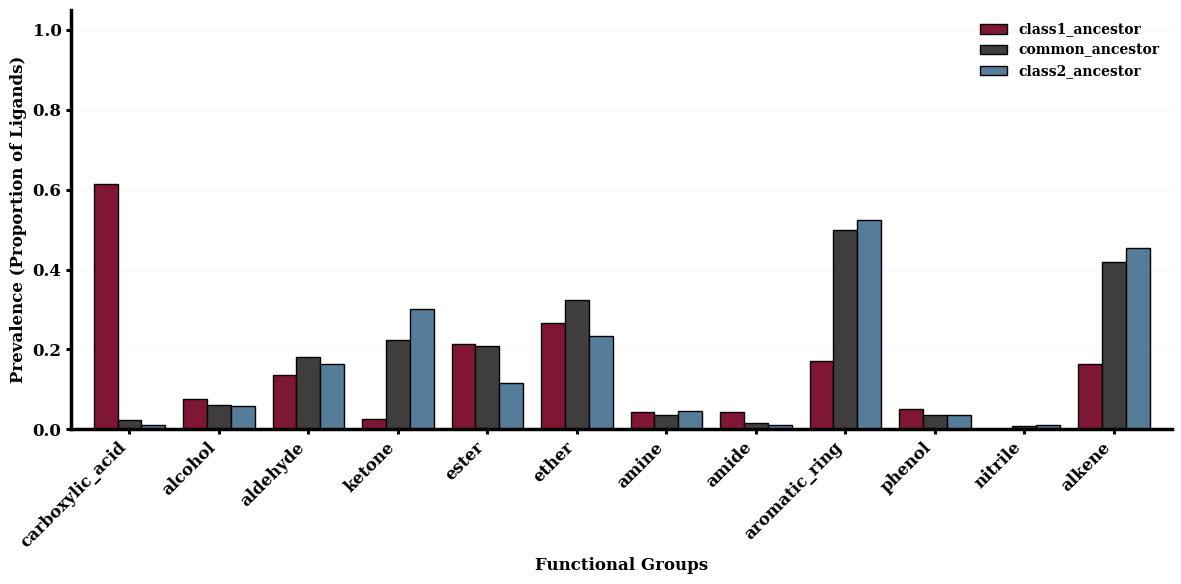

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# Set the plot style
plt.style.use(custom_plots()) # Using your custom style function
colors = ["#7f1734ff", "#403e3dff", "#557c99ff"] 

# Plotting
ax = fg_prevalence_3.plot(
    kind='bar', 
    figsize=(12, 6), 
    color=colors,
    width=0.8,
    edgecolor='black',
    linewidth=1
)

#plt.title("Functional Group Prevalence across Ancestral Sets", fontsize=14, pad=20)
plt.ylabel("Prevalence (Proportion of Ligands)")
plt.xlabel("Functional Groups")
plt.xticks(rotation=45, ha='right')
plt.legend(frameon=False)
plt.ylim(0, 1.05) # Proportion range

plt.gca().set_axisbelow(True)                                    # grid behind boxes
plt.grid(axis="y", linestyle="--", alpha=0.2)

plt.tight_layout()

plt.savefig("functional_group_prevalence_ancestral_sets.png", bbox_inches="tight", transparent=True, dpi=300)
plt.show()

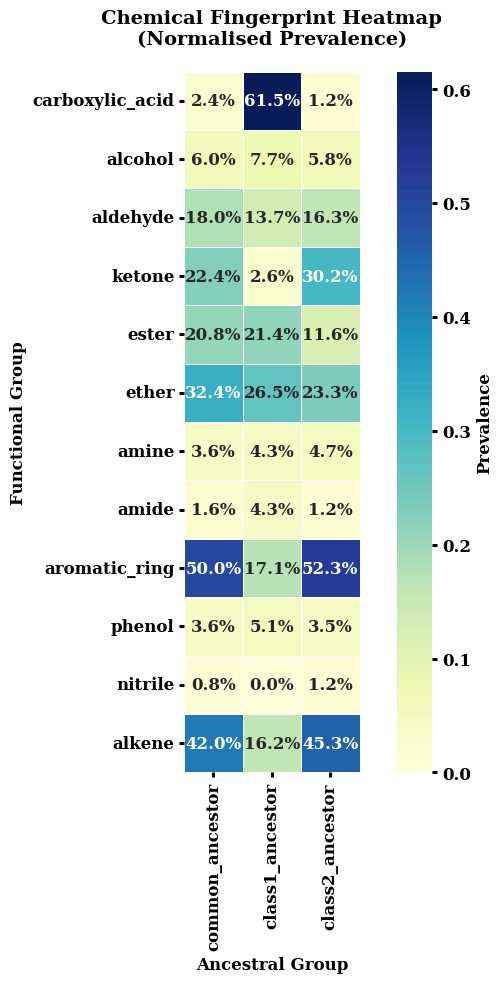

In [54]:
import seaborn as sns

plt.figure(figsize=(8, 10))

# Create heatmap
# fmt=".1%" converts 0.123 to 12.3% for better readability
sns.heatmap(
    fg_prevalence_3, 
    annot=True, 
    fmt=".1%", 
    cmap="YlGnBu", 
    cbar_kws={'label': 'Prevalence'},
    linewidths=.5,
    square=True
)

plt.title("Chemical Fingerprint Heatmap\n(Normalised Prevalence)", fontsize=14, pad=20)
plt.xlabel("Ancestral Group")
plt.ylabel("Functional Group")

plt.tight_layout()
plt.show()

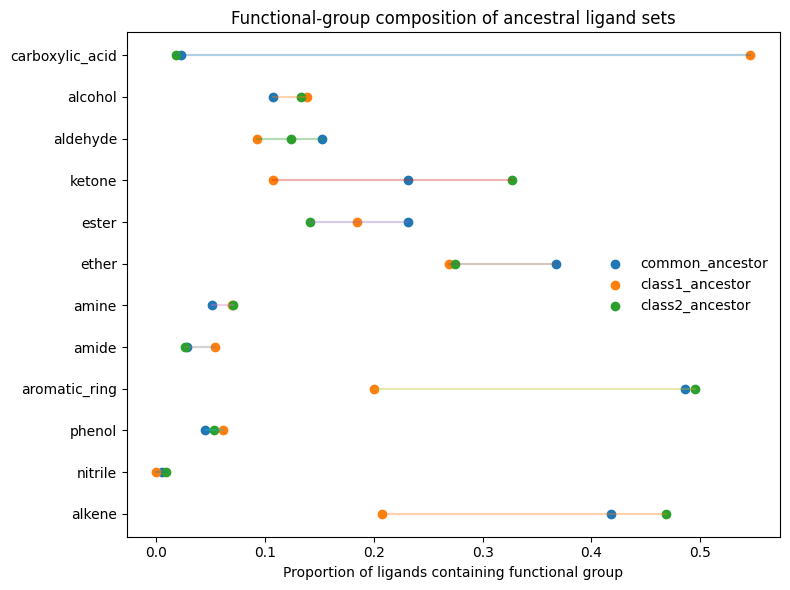

In [35]:
plot_fg = fg_prevalence_3.reset_index().rename(columns={"index": "functional_group"})
y = np.arange(len(plot_fg))

plt.figure(figsize=(8,6))
plt.scatter(plot_fg["common_ancestor"], y, label="common_ancestor")
plt.scatter(plot_fg["class1_ancestor"], y, label="class1_ancestor")
plt.scatter(plot_fg["class2_ancestor"], y, label="class2_ancestor")

for i, row in plot_fg.iterrows():
    vals = [row["common_ancestor"], row["class1_ancestor"], row["class2_ancestor"]]
    plt.plot(vals, [i, i, i], alpha=0.35)

plt.yticks(y, plot_fg["functional_group"])
plt.xlabel("Proportion of ligands containing functional group")
plt.title("Functional-group composition of ancestral ligand sets")
plt.legend(frameon=False)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

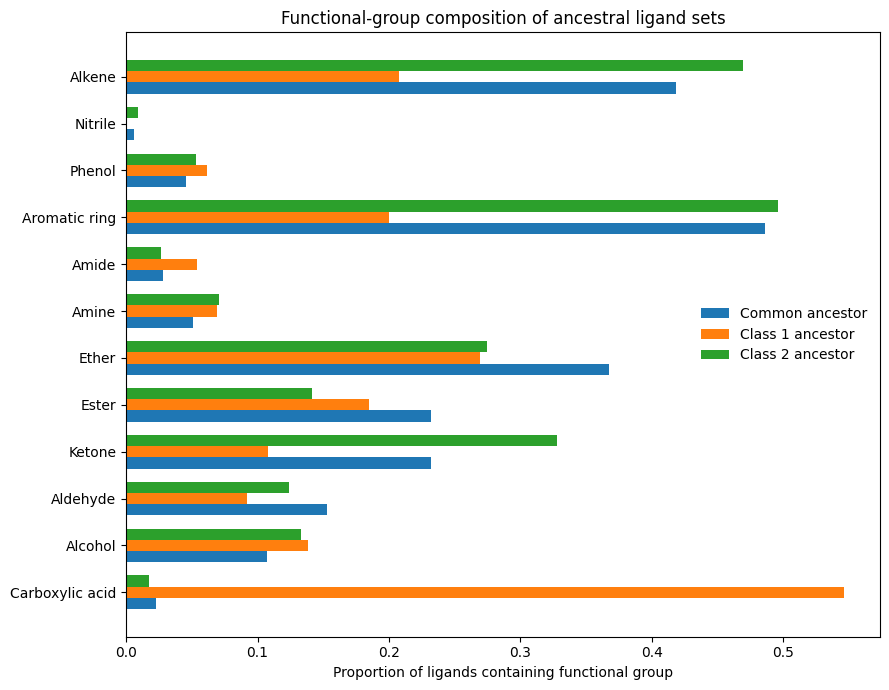

In [36]:
fg_cols = [
    "carboxylic_acid", "alcohol", "aldehyde", "ketone", "ester",
    "ether", "amine", "amide", "aromatic_ring", "phenol",
    "nitrile", "alkene"
]

plot_order = ["common_ancestor", "class1_ancestor", "class2_ancestor"]

fg_prevalence_3 = (
    compare3_df.groupby("group")[fg_cols]
    .mean()
    .loc[plot_order]
    .T
)

# optional: prettier labels
label_map = {
    "carboxylic_acid": "Carboxylic acid",
    "alcohol": "Alcohol",
    "aldehyde": "Aldehyde",
    "ketone": "Ketone",
    "ester": "Ester",
    "ether": "Ether",
    "amine": "Amine",
    "amide": "Amide",
    "aromatic_ring": "Aromatic ring",
    "phenol": "Phenol",
    "nitrile": "Nitrile",
    "alkene": "Alkene"
}
fg_prevalence_3.index = [label_map[x] for x in fg_prevalence_3.index]

y = np.arange(len(fg_prevalence_3))
h = 0.24

plt.figure(figsize=(9, 7))
plt.barh(y - h, fg_prevalence_3["common_ancestor"], height=h, label="Common ancestor")
plt.barh(y,     fg_prevalence_3["class1_ancestor"], height=h, label="Class 1 ancestor")
plt.barh(y + h, fg_prevalence_3["class2_ancestor"], height=h, label="Class 2 ancestor")

plt.yticks(y, fg_prevalence_3.index)
plt.xlabel("Proportion of ligands containing functional group")
plt.title("Functional-group composition of ancestral ligand sets")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

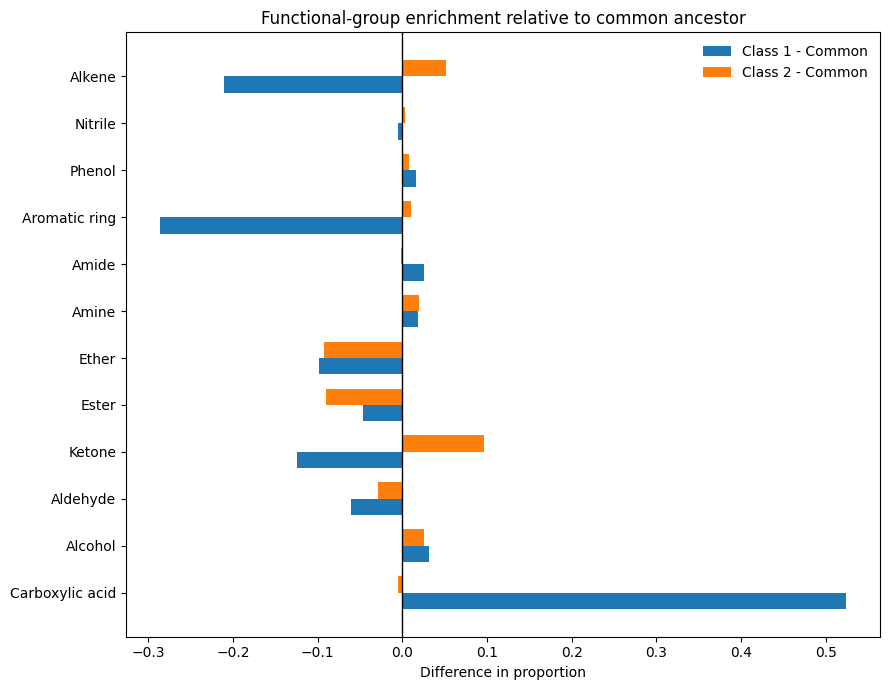

In [37]:
fg_diff = pd.DataFrame({
    "Class 1 - Common": fg_prevalence_3["class1_ancestor"] - fg_prevalence_3["common_ancestor"],
    "Class 2 - Common": fg_prevalence_3["class2_ancestor"] - fg_prevalence_3["common_ancestor"],
})

y = np.arange(len(fg_diff))
h = 0.35

plt.figure(figsize=(9, 7))
plt.barh(y - h/2, fg_diff["Class 1 - Common"], height=h, label="Class 1 - Common")
plt.barh(y + h/2, fg_diff["Class 2 - Common"], height=h, label="Class 2 - Common")

plt.axvline(0, color="black", linewidth=1)
plt.yticks(y, fg_diff.index)
plt.xlabel("Difference in proportion")
plt.title("Functional-group enrichment relative to common ancestor")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [55]:
from scipy.stats import mannwhitneyu
import numpy as np
import pandas as pd

def logp_test(df, group1, group2):
    x = df.loc[df["group"] == group1, "logP"].dropna().values
    y = df.loc[df["group"] == group2, "logP"].dropna().values
    
    # one-sided: class1 expected lower
    stat, p = mannwhitneyu(x, y, alternative="less")
    
    return {
        "group1": group1,
        "group2": group2,
        "n1": len(x),
        "n2": len(y),
        "median1": np.median(x),
        "median2": np.median(y),
        "U_stat": stat,
        "p_value": p
    }

logp_results = pd.DataFrame([
    logp_test(compare3_df, "class1_ancestor", "common_ancestor"),
    logp_test(compare3_df, "class1_ancestor", "class2_ancestor")
])

logp_results

,group1,group2,n1,n2,median1,median2,U_stat,p_value
0,class1_ancestor,common_ancestor,130,177,2.0856,2.5496,9279.0,0.001890
1,class1_ancestor,class2_ancestor,130,113,2.0856,2.5800,5787.5,0.002193


In [56]:
from scipy.stats import fisher_exact

def fg_test(df, fg, group1, group2):
    sub1 = df[df["group"] == group1]
    sub2 = df[df["group"] == group2]
    
    a = int((sub1[fg] == 1).sum())  # group1 present
    b = int((sub1[fg] == 0).sum())  # group1 absent
    c = int((sub2[fg] == 1).sum())  # group2 present
    d = int((sub2[fg] == 0).sum())  # group2 absent
    
    # one-sided: group1 enriched
    odds_ratio, p = fisher_exact([[a, b], [c, d]], alternative="greater")
    
    return {
        "group1": group1,
        "group2": group2,
        "functional_group": fg,
        "present_1": a,
        "total_1": a + b,
        "prop_1": a / (a + b),
        "present_2": c,
        "total_2": c + d,
        "prop_2": c / (c + d),
        "odds_ratio": odds_ratio,
        "p_value": p
    }

acid_results = pd.DataFrame([
    fg_test(compare3_df, "carboxylic_acid", "class1_ancestor", "common_ancestor"),
    fg_test(compare3_df, "carboxylic_acid", "class1_ancestor", "class2_ancestor")
])

acid_results

,group1,group2,functional_group,present_1,total_1,prop_1,present_2,total_2,prop_2,odds_ratio,p_value
0,class1_ancestor,common_ancestor,carboxylic_acid,71,130,0.546154,4,177,0.022599,52.046610,3.102598e-28
1,class1_ancestor,class2_ancestor,carboxylic_acid,71,130,0.546154,2,113,0.017699,66.788136,1.981157e-22


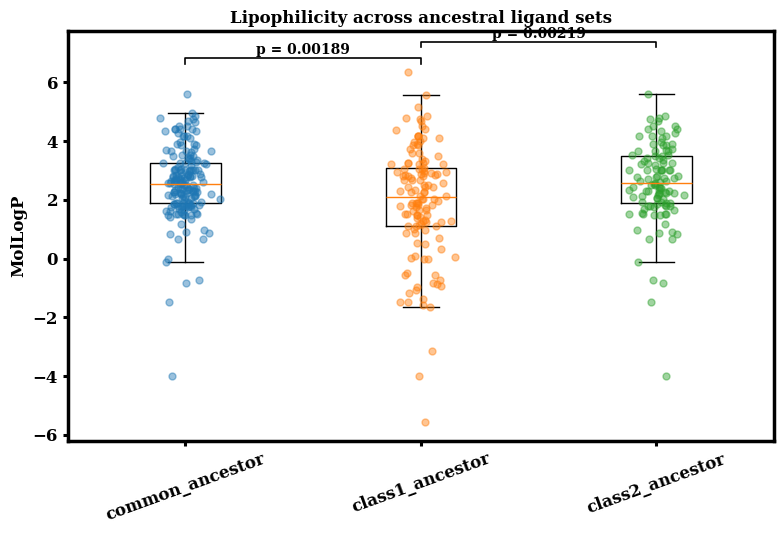

In [57]:
plot_order = ["common_ancestor", "class1_ancestor", "class2_ancestor"]

# data
data_to_plot = [
    compare3_df.loc[compare3_df["group"] == g, "logP"].dropna().values
    for g in plot_order
]

fig, ax = plt.subplots(figsize=(8, 5.5))

# boxplot
ax.boxplot(data_to_plot, tick_labels=plot_order, showfliers=False)

# raw points
rng = np.random.default_rng(42)
for i, g in enumerate(plot_order, start=1):
    y = compare3_df.loc[compare3_df["group"] == g, "logP"].dropna().values
    x = rng.normal(i, 0.05, size=len(y))
    ax.plot(x, y, "o", alpha=0.45)

ax.set_ylabel("MolLogP")
ax.set_title("Lipophilicity across ancestral ligand sets")
ax.set_xticklabels(plot_order, rotation=20)

# ---------- significance brackets ----------
def add_pvalue_bracket(ax, x1, x2, y, h, text):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.2, c="black")
    ax.text((x1 + x2) / 2, y + h + 0.05, text, ha="center", va="bottom", fontsize=10)

ymax = max(np.max(d) for d in data_to_plot)
base = ymax + 0.3

# class1 vs common
add_pvalue_bracket(ax, 1, 2, base, 0.18, "p = 0.00189")

# class1 vs class2
add_pvalue_bracket(ax, 2, 3, base + 0.55, 0.18, "p = 0.00219")

ax.set_ylim(top=base + 1.1)
plt.tight_layout()
plt.show()

### 6 groups

In [59]:
summary = (
    compare_df.groupby("group")[["logP", "TPSA", "MW", "HBD", "HBA"]]
    .agg(["count", "median", "mean"])
)

summary

logP                    TPSA                      MW  \
                count  median      mean count median       mean count   
group                                                                   
class1_ancestor   130  2.0856  1.919074   130  37.30  50.722923   130   
class1_gains       89  1.8174  1.616702    89  37.30  51.146404    89   
class1_losses     136  2.4448  2.543417   136  18.46  22.028750   136   
class2_ancestor   113  2.5800  2.575651   113  18.46  30.655752   113   
class2_losses      64  2.5089  2.507021    64  26.30  24.590000    64   
common_ancestor   177  2.5496  2.550835   177  20.23  28.462486   177   

                                       HBD                    HBA         \
                  median        mean count median      mean count median   
group                                                                      
class1_ancestor  170.274  190.941185   130    1.0  1.261538   130    2.0   
class1_gains     158.241  167.237438    89    1.0  1.370787    89    1.0   
class1_losses    154.253  165.259618   136    0.0  0.169118   136    1.0   
class2_ancestor  165.236  190.388841   113    0.0  0.460177   113    1.0   
class2_losses    162.210  170.306109    64    0.0  0.203125    64    2.0   
common_ancestor  164.204  183.127288   177    0.0  0.367232   177    2.0   

                           
                     mean  
group                      
class1_ancestor  2.084615  
class1_gains     1.831461  
class1_losses    1.551471  
class2_ancestor  1.849558  
class2_losses    1.718750  
common_ancestor  1.802260

In [60]:
median_table = (
    compare_df.groupby("group")[["logP", "TPSA", "MW", "HBD", "HBA"]]
    .median()
    .sort_index()
)

median_table

,logP,TPSA,MW,HBD,HBA
group,,,,,
class1_ancestor,2.0856,37.30,170.274,1.0,2.0
class1_gains,1.8174,37.30,158.241,1.0,1.0
class1_losses,2.4448,18.46,154.253,0.0,1.0
class2_ancestor,2.5800,18.46,165.236,0.0,1.0
class2_losses,2.5089,26.30,162.210,0.0,2.0
common_ancestor,2.5496,20.23,164.204,0.0,2.0


In [61]:
fg_cols = list(fg_smarts.keys())

fg_prevalence = (
    compare_df.groupby("group")[fg_cols]
    .mean()
    .T
)

fg_prevalence

group,class1_ancestor,class1_gains,class1_losses,class2_ancestor,class2_losses,common_ancestor
carboxylic_acid,0.546154,0.764045,0.007353,0.017699,0.031250,0.022599
alcohol,0.138462,0.078652,0.058824,0.132743,0.062500,0.107345
aldehyde,0.092308,0.089888,0.169118,0.123894,0.203125,0.152542
ketone,0.107692,0.033708,0.220588,0.327434,0.062500,0.231638
ester,0.184615,0.123596,0.205882,0.141593,0.390625,0.231638
ether,0.269231,0.191011,0.345588,0.274336,0.531250,0.367232
amine,0.069231,0.056180,0.036765,0.070796,0.015625,0.050847
amide,0.053846,0.056180,0.022059,0.026549,0.031250,0.028249
aromatic_ring,0.200000,0.112360,0.514706,0.495575,0.468750,0.485876
phenol,0.061538,0.044944,0.029412,0.053097,0.031250,0.045198


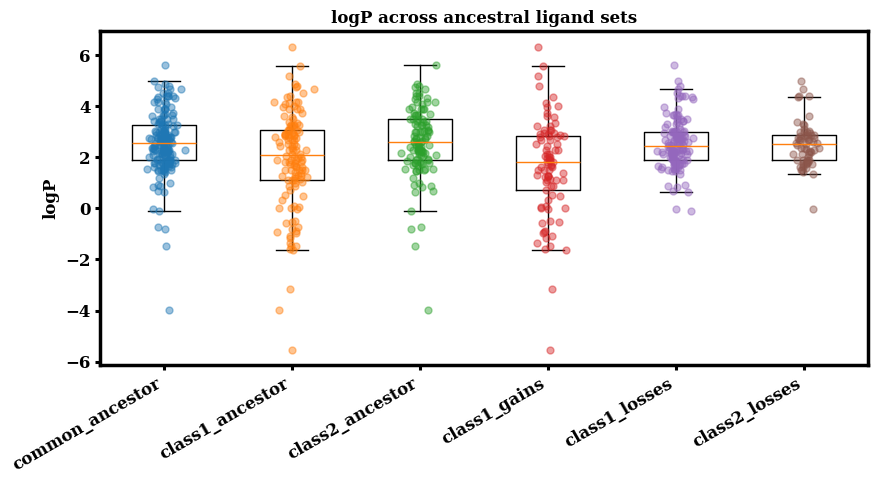

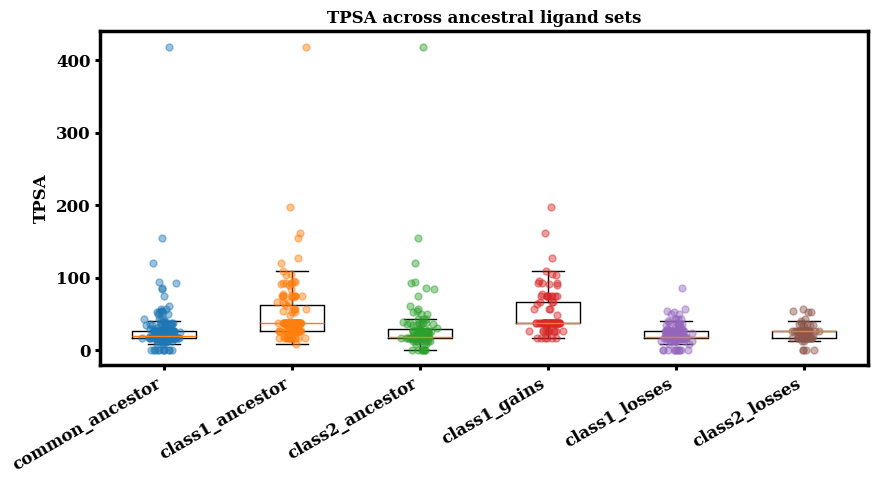

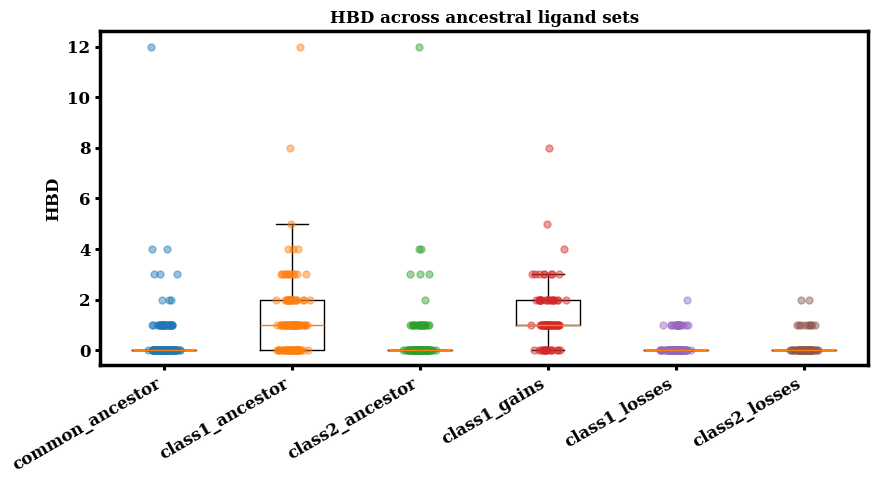

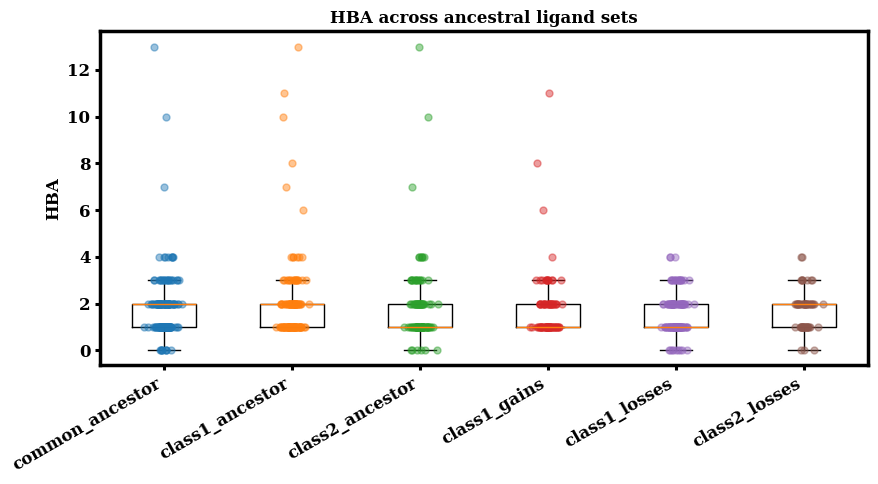

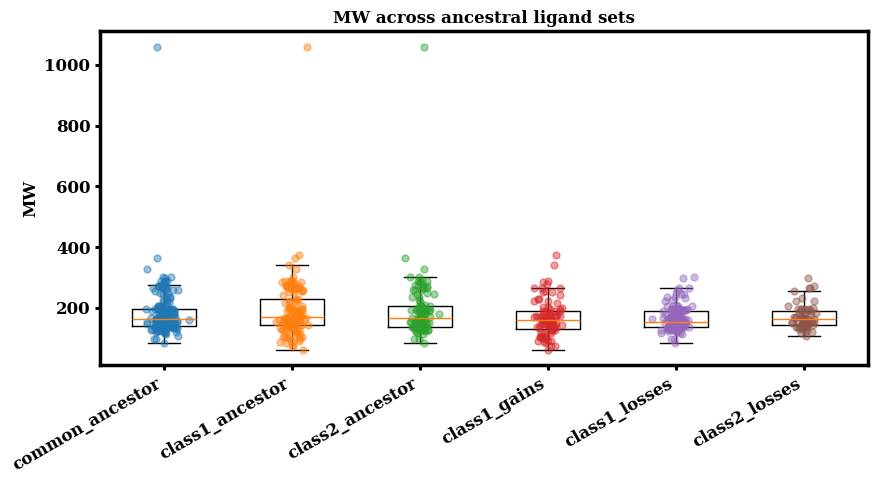

In [62]:
plot_order = [
    "common_ancestor",
    "class1_ancestor",
    "class2_ancestor",
    "class1_gains",
    "class1_losses",
    "class2_losses"
]

for desc in ["logP", "TPSA", "HBD", "HBA", "MW"]:
    plt.figure(figsize=(9,5))
    
    data_to_plot = [
        compare_df.loc[compare_df["group"] == g, desc].dropna().values
        for g in plot_order
    ]
    
    plt.boxplot(data_to_plot, tick_labels=plot_order, showfliers=False)
    
    for i, g in enumerate(plot_order, start=1):
        y = compare_df.loc[compare_df["group"] == g, desc].dropna().values
        x = np.random.normal(i, 0.05, size=len(y))
        plt.plot(x, y, "o", alpha=0.45)
    
    plt.ylabel(desc)
    plt.title(f"{desc} across ancestral ligand sets")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

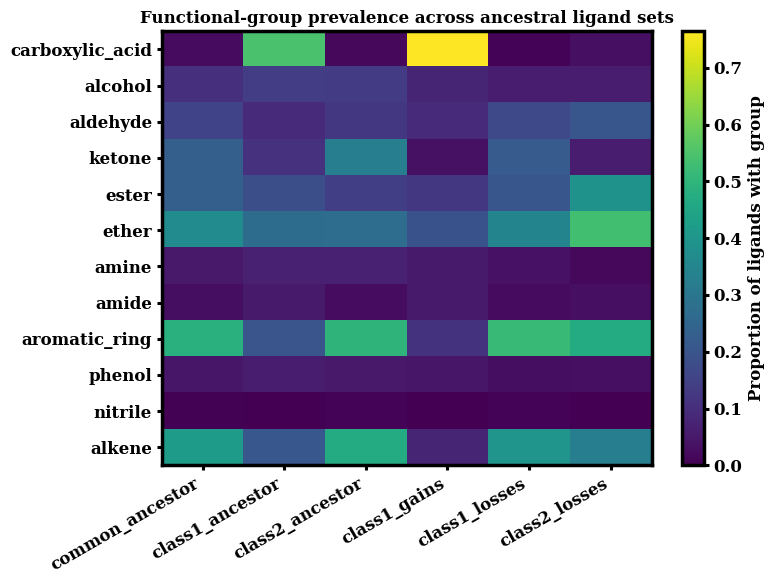

In [63]:
plt.figure(figsize=(8,6))
plt.imshow(fg_prevalence[plot_order].values, aspect="auto")
plt.colorbar(label="Proportion of ligands with group")
plt.yticks(range(len(fg_prevalence.index)), fg_prevalence.index)
plt.xticks(range(len(plot_order)), plot_order, rotation=30, ha="right")
plt.title("Functional-group prevalence across ancestral ligand sets")
plt.tight_layout()
plt.show()

## Activation Patterns analysis

In [24]:
fg_cols = [
    "carboxylic_acid", "alcohol", "aldehyde", "ketone", "ester",
    "ether", "amine", "amide", "aromatic_ring", "phenol",
    "nitrile", "alkene"
]

desc_cols = ["logP", "TPSA", "MW", "HBD", "HBA"]

pattern_analysis_df = (
    pattern_df
    .merge(desc_df, on="SMILES", how="left")
    .merge(fg_df, on="SMILES", how="left")
    .copy()
)

observed_patterns = ["100", "111", "011", "010", "110"]
pattern_analysis_df = pattern_analysis_df[
    pattern_analysis_df["pattern"].isin(observed_patterns)
].copy()

# broader biological grouping
def assign_pattern_group(p):
    if p in ["100", "110"]:
        return "class1_side"
    elif p == "111":
        return "combinatorial_111"
    else:
        return "other_patterns"

pattern_analysis_df["pattern_group"] = pattern_analysis_df["pattern"].apply(assign_pattern_group)

pattern_analysis_df

,SMILES,pattern,logP,TPSA,MW,HBD,HBA,carboxylic_acid,alcohol,aldehyde,ketone,ester,ether,amine,amide,aromatic_ring,phenol,nitrile,alkene,pattern_group
0,C(C(=O)C(=O)O)O,100,-1.3676,74.60,104.061,2,3,1,1,0,1,0,0,0,0,0,0,0,0,class1_side
1,C(C(=O)O)N,100,-0.9703,63.32,75.067,2,2,1,0,0,0,0,0,1,0,0,0,0,0,class1_side
2,C(C(=O)O)S,100,0.0008,37.30,92.119,2,2,1,0,0,0,0,0,0,0,0,0,0,0,class1_side
3,C(C(C(=O)O)N)N,100,-1.6430,89.34,104.109,3,3,1,0,0,0,0,0,1,0,0,0,0,0,class1_side
4,C(C(C=O)O)O,100,-1.4615,57.53,90.078,2,3,0,1,1,0,0,0,0,0,0,0,0,0,class1_side
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,C[C@]12CC[C@H]3[C@H]([C@@H]1CCC2=O)CCC4=CC(=O)...,111,3.0598,54.37,302.414,1,3,0,1,0,1,0,0,0,0,0,0,0,1,combinatorial_111
262,C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@@H]2O)CCC4=CC...,111,3.4891,37.30,274.404,1,2,0,1,0,1,0,0,0,0,0,0,0,1,combinatorial_111
263,C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@@H]2O)CCC4=CC...,111,3.8792,37.30,288.431,1,2,0,1,0,1,0,0,0,0,0,0,0,1,combinatorial_111
264,C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@H]2O)CCC4=CC(...,111,3.8792,37.30,288.431,1,2,0,1,0,1,0,0,0,0,0,0,0,1,combinatorial_111


In [25]:
pattern_counts = pattern_analysis_df["pattern"].value_counts().reindex(observed_patterns)
print(pattern_counts)

group_counts = pattern_analysis_df["pattern_group"].value_counts()
print(group_counts)

pattern
100    89
111    27
011    86
010    50
110    14
Name: count, dtype: int64
pattern_group
other_patterns       136
class1_side          103
combinatorial_111     27
Name: count, dtype: int64


### ***a+e against c*** (exclude shared)

In [32]:
import pandas as pd

two_group_df = pattern_analysis_df[
    pattern_analysis_df["pattern"].isin(["100", "110", "011"])
].copy()

two_group_df["comparison_group"] = two_group_df["pattern"].apply(
    lambda p: "class1_side" if p in ["100", "110"] else "class2_side"
)

two_group_df["comparison_group"].value_counts()

comparison_group
class1_side    103
class2_side     86
Name: count, dtype: int64

In [ ]:
two_group_df

,SMILES,pattern,logP,TPSA,MW,HBD,HBA,carboxylic_acid,alcohol,aldehyde,...,ester,ether,amine,amide,aromatic_ring,phenol,nitrile,alkene,pattern_group,comparison_group
0,C(C(=O)C(=O)O)O,100,-1.3676,74.60,104.061,2,3,1,1,0,...,0,0,0,0,0,0,0,0,class1_side,class1_side
1,C(C(=O)O)N,100,-0.9703,63.32,75.067,2,2,1,0,0,...,0,0,1,0,0,0,0,0,class1_side,class1_side
2,C(C(=O)O)S,100,0.0008,37.30,92.119,2,2,1,0,0,...,0,0,0,0,0,0,0,0,class1_side,class1_side
3,C(C(C(=O)O)N)N,100,-1.6430,89.34,104.109,3,3,1,0,0,...,0,0,1,0,0,0,0,0,class1_side,class1_side
4,C(C(C=O)O)O,100,-1.4615,57.53,90.078,2,3,0,1,1,...,0,0,0,0,0,0,0,0,class1_side,class1_side
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
250,C[C@@H]1CCO[C@H](C1)C=C(C)C,011,2.7677,9.23,154.253,0,1,0,0,0,...,0,1,0,0,0,0,0,1,other_patterns,class2_side
253,C[C@@]12CC[C@@H](C1(C)C)CC2=O,011,2.4017,17.07,152.237,0,1,0,0,0,...,0,0,0,0,0,0,0,0,other_patterns,class2_side
254,C[C@H](C(=O)N[C@H](C)C(=O)O)N,100,-1.0771,92.42,160.173,3,3,1,0,0,...,0,0,1,1,0,0,0,0,class1_side,class1_side
255,C[C@H]1CC(C2=C(C1(C)C)C[C@@]3([C@H](C2)O3)C)(C)C,011,4.3265,12.53,234.383,0,1,0,0,0,...,0,1,0,0,0,0,0,1,other_patterns,class2_side


In [33]:
desc_cols = ["logP", "TPSA", "MW", "HBD", "HBA"]

median_table = (
    two_group_df.groupby("comparison_group")[desc_cols]
    .median()
)

median_table

,logP,TPSA,MW,HBD,HBA
comparison_group,,,,,
class1_side,1.8822,37.30,158.241,1.0,1.0
class2_side,2.4017,17.07,150.221,0.0,1.0


In [34]:
summary_table = (
    two_group_df.groupby("comparison_group")[desc_cols]
    .agg(["count", "median", "mean"])
)

summary_table

logP                    TPSA                      MW  \
                 count  median      mean count median       mean count   
comparison_group                                                         
class1_side        103  1.8822  1.732603   103  37.30  48.272524   103   
class2_side         86  2.4017  2.558453    86  17.07  21.420814    86   

                                        HBD                    HBA         \
                   median        mean count median      mean count median   
comparison_group                                                            
class1_side       158.241  168.014117   103    1.0  1.223301   103    1.0   
class2_side       150.221  162.756267    86    0.0  0.162791    86    1.0   

                            
                      mean  
comparison_group            
class1_side       1.834951  
class2_side       1.476744

In [40]:
from scipy.stats import mannwhitneyu
import numpy as np
import pandas as pd


def mw_test(
    df,
    value_col,
    alternative="two-sided",
    group_col="comparison_group",
    group_labels=("class1_side", "class2_side"),
):
    x = df.loc[df[group_col] == group_labels[0], value_col].dropna().values
    y = df.loc[df[group_col] == group_labels[1], value_col].dropna().values

    if len(x) == 0 or len(y) == 0:
        raise ValueError(f"One or both groups are empty for '{value_col}'")

    stat, p = mannwhitneyu(x, y, alternative=alternative)

    n = len(x) * len(y)
    r = 1 - (2 * stat) / n  # rank-biserial correlation [-1, 1]

    return {
        "descriptor": value_col,
        "n_class1": len(x),
        "n_class2": len(y),
        "median_class1": np.median(x),
        "median_class2": np.median(y),
        "U_stat": stat,
        "p_value": p,
        "effect_size_r": r,
    }


tests = [
    ("logP", "less"),
    ("TPSA", "greater"),
    ("HBD",  "greater"),
    ("HBA",  "greater"),
    ("MW",   "two-sided"),
]

descriptor_stats = pd.DataFrame([
    mw_test(two_group_df, col, alternative=alt) for col, alt in tests
])

descriptor_stats

,descriptor,n_class1,n_class2,median_class1,median_class2,U_stat,p_value,effect_size_r
0,logP,103,86,1.8822,2.4017,3115.5,2.274013e-04,0.296568
1,TPSA,103,86,37.3000,17.0700,7569.5,9.519053e-18,-0.709077
2,HBD,103,86,1.0000,0.0000,7157.0,4.955841e-16,-0.615940
3,HBA,103,86,1.0000,1.0000,5057.5,3.216798e-02,-0.141906
4,MW,103,86,158.2410,150.2210,4534.5,7.791855e-01,-0.023820


In [26]:
from matplotlib.patches import Patch
import seaborn as sns

pattern_order = ["100", "110", "111", "011", "010"]

pattern_labels = {
    "100": "Class 1 only",
    "111": "All three",
    "011": "Common + Class 2",
    "010": "Common only",
    "110": "Class 1 + Common"
}

pat_palette = dict(zip(pattern_order, sns.color_palette("Accent", n_colors=len(pattern_order))))

handles = [
    Patch(facecolor=pat_palette[p], edgecolor="none", label=f"{p}: {pattern_labels[p]}")
    for p in pattern_order
]

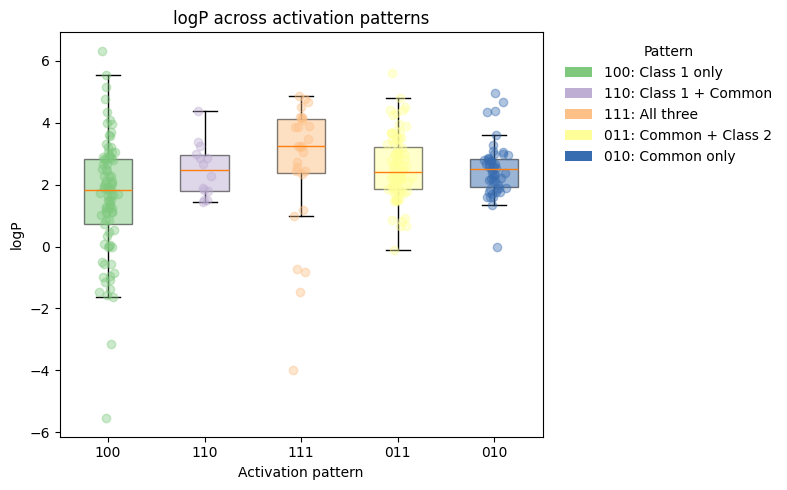

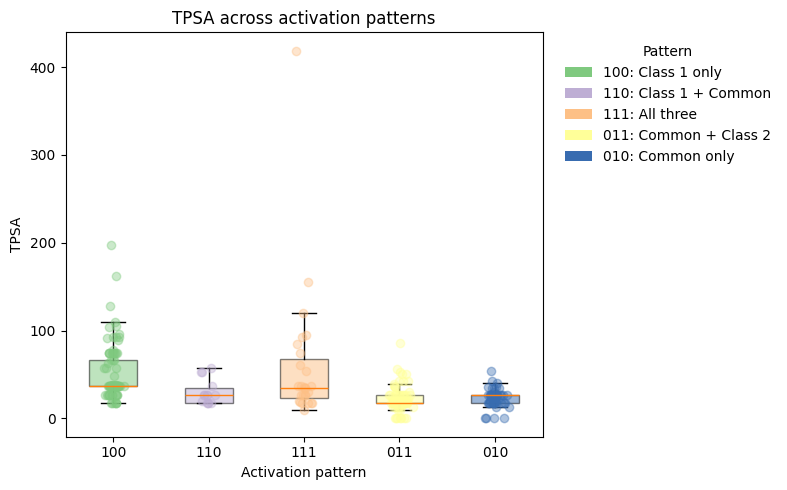

In [27]:
for desc in ["logP", "TPSA"]:
    fig, ax = plt.subplots(figsize=(8, 5))

    data_to_plot = [
        pattern_analysis_df.loc[pattern_analysis_df["pattern"] == p, desc].dropna().values
        for p in pattern_order
    ]

    bp = ax.boxplot(data_to_plot, tick_labels=pattern_order, showfliers=False, patch_artist=True)

    for patch, p in zip(bp["boxes"], pattern_order):
        patch.set_facecolor(pat_palette[p])
        patch.set_alpha(0.5)

    rng = np.random.default_rng(42)
    for i, p in enumerate(pattern_order, start=1):
        y = pattern_analysis_df.loc[pattern_analysis_df["pattern"] == p, desc].dropna().values
        x = rng.normal(i, 0.05, size=len(y))
        ax.plot(x, y, "o", alpha=0.4, color=pat_palette[p])

    ax.set_ylabel(desc)
    ax.set_xlabel("Activation pattern")
    ax.set_title(f"{desc} across activation patterns")

    ax.legend(handles=handles, title="Pattern", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)

    plt.tight_layout()
    plt.show()

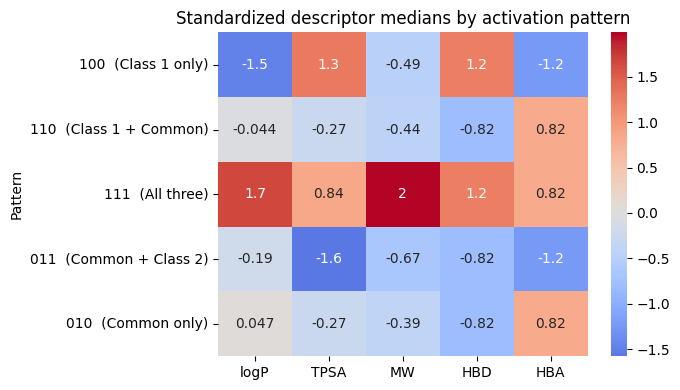

In [28]:
import seaborn as sns

descriptor_summary = (
    pattern_analysis_df.groupby("pattern")[desc_cols]
    .median()
    .reindex(pattern_order)
)

descriptor_summary_z = descriptor_summary.apply(
    lambda col: (col - col.mean()) / col.std(ddof=0),
    axis=0
)

pretty_index = [f"{p}  ({pattern_labels[p]})" for p in pattern_order]
descriptor_summary.index = pretty_index
descriptor_summary_z.index = pretty_index

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(descriptor_summary_z, cmap="coolwarm", center=0, annot=True, ax=ax)

ax.set_title("Standardized descriptor medians by activation pattern")
ax.set_ylabel("Pattern")
#ax.legend(handles=handles, title="Pattern", bbox_to_anchor=(1.35, 1), loc="upper left", frameon=False)

plt.tight_layout()
plt.show()

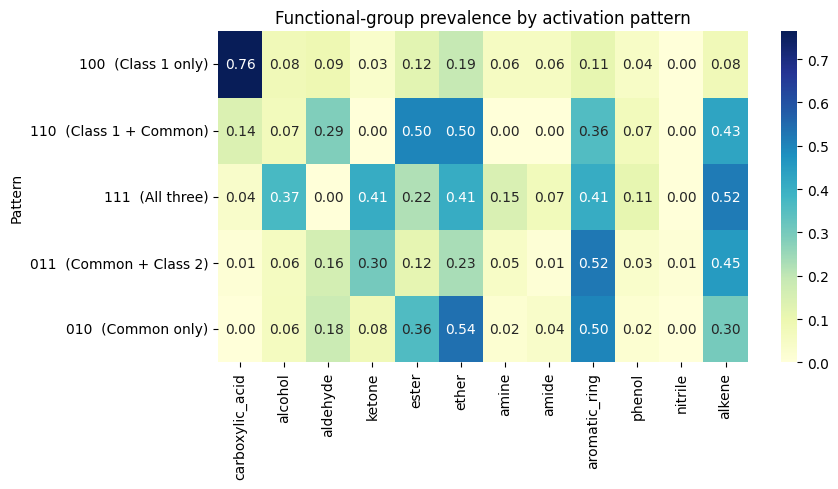

In [29]:
fg_prev_by_pattern = (
    pattern_analysis_df.groupby("pattern")[fg_cols]
    .mean()
    .reindex(pattern_order)
)


pretty_index = [f"{p}  ({pattern_labels[p]})" for p in pattern_order]
fg_prev_by_pattern.index = pretty_index
descriptor_summary_z.index = pretty_index

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(fg_prev_by_pattern, cmap="YlGnBu", annot=True, fmt=".2f", ax=ax)

ax.set_title("Functional-group prevalence by activation pattern")
ax.set_ylabel("Pattern")
#ax.legend(handles=handles, title="Pattern", bbox_to_anchor=(1.32, 1), loc="upper left", frameon=False)

plt.tight_layout()
plt.show()

In [30]:
### test across all five patterns ###
from scipy.stats import kruskal

for desc in ["logP", "TPSA", "HBD", "HBA", "MW"]:
    groups = [
        pattern_analysis_df.loc[pattern_analysis_df["pattern"] == p, desc].dropna().values
        for p in pattern_order
    ]
    stat, p = kruskal(*groups)
    print(desc, stat, p)

logP 22.799135811335304 0.00013887917048213965
TPSA 99.98596002626041 9.904556622929691e-21
HBD 102.08708422207215 3.53539685777084e-21
HBA 18.048600384576652 0.0012073975415117153
MW 41.1528826343915 2.4988770887342695e-08


In [53]:
### Class 1 side vs 111 ###
from scipy.stats import mannwhitneyu

def mw_test(df, group_col, value_col, g1, g2, alternative="two-sided"):
    x = df.loc[df[group_col] == g1, value_col].dropna().values
    y = df.loc[df[group_col] == g2, value_col].dropna().values
    stat, p = mannwhitneyu(x, y, alternative=alternative)
    return {
        "group1": g1,
        "group2": g2,
        "descriptor": value_col,
        "median1": np.median(x),
        "median2": np.median(y),
        "U_stat": stat,
        "p_value": p
    }

mw_results = pd.DataFrame([
    mw_test(pattern_analysis_df, "pattern_group", "logP", "class1_side", "combinatorial_111", alternative="less"),
    mw_test(pattern_analysis_df, "pattern_group", "TPSA", "class1_side", "combinatorial_111", alternative="greater"),
    mw_test(pattern_analysis_df, "pattern_group", "HBD", "class1_side", "combinatorial_111", alternative="greater"),
    mw_test(pattern_analysis_df, "pattern_group", "HBA", "class1_side", "combinatorial_111", alternative="greater"),
])

mw_results

,group1,group2,descriptor,median1,median2,U_stat,p_value
0,class1_side,combinatorial_111,logP,1.8822,3.2422,858.0,0.001132
1,class1_side,combinatorial_111,TPSA,37.3000,34.1400,1587.0,0.124297
2,class1_side,combinatorial_111,HBD,1.0000,1.0000,1579.0,0.128530
3,class1_side,combinatorial_111,HBA,1.0000,2.0000,889.0,0.999019


In [54]:
### functional-group enrichment for class 1 side vs 111 ###
from scipy.stats import fisher_exact

def fisher_fg(df, group_col, fg, g1, g2):
    sub1 = df[df[group_col] == g1]
    sub2 = df[df[group_col] == g2]
    
    a = int((sub1[fg] == 1).sum())
    b = int((sub1[fg] == 0).sum())
    c = int((sub2[fg] == 1).sum())
    d = int((sub2[fg] == 0).sum())
    
    odds_ratio, p = fisher_exact([[a, b], [c, d]], alternative="greater")
    
    return {
        "functional_group": fg,
        "group1": g1,
        "group2": g2,
        "prop_1": a / (a + b),
        "prop_2": c / (c + d),
        "odds_ratio": odds_ratio,
        "p_value": p
    }

fg_enrich_results = pd.DataFrame([
    fisher_fg(pattern_analysis_df, "pattern_group", fg, "class1_side", "combinatorial_111")
    for fg in fg_cols
]).sort_values("p_value")

fg_enrich_results

,functional_group,group1,group2,prop_1,prop_2,odds_ratio,p_value
0,carboxylic_acid,class1_side,combinatorial_111,0.679612,0.037037,55.151515,4.769159e-10
2,aldehyde,class1_side,combinatorial_111,0.116505,0.000000,inf,5.305884e-02
4,ester,class1_side,combinatorial_111,0.174757,0.222222,0.741176,8.036335e-01
7,amide,class1_side,combinatorial_111,0.048544,0.074074,0.637755,8.438868e-01
9,phenol,class1_side,combinatorial_111,0.048544,0.111111,0.408163,9.424206e-01
5,ether,class1_side,combinatorial_111,0.233010,0.407407,0.441887,9.779031e-01
6,amine,class1_side,combinatorial_111,0.048544,0.148148,0.293367,9.811880e-01
8,aromatic_ring,class1_side,combinatorial_111,0.145631,0.407407,0.247934,9.990717e-01
1,alcohol,class1_side,combinatorial_111,0.077670,0.370370,0.143158,9.999443e-01
11,alkene,class1_side,combinatorial_111,0.126214,0.518519,0.134127,9.999951e-01


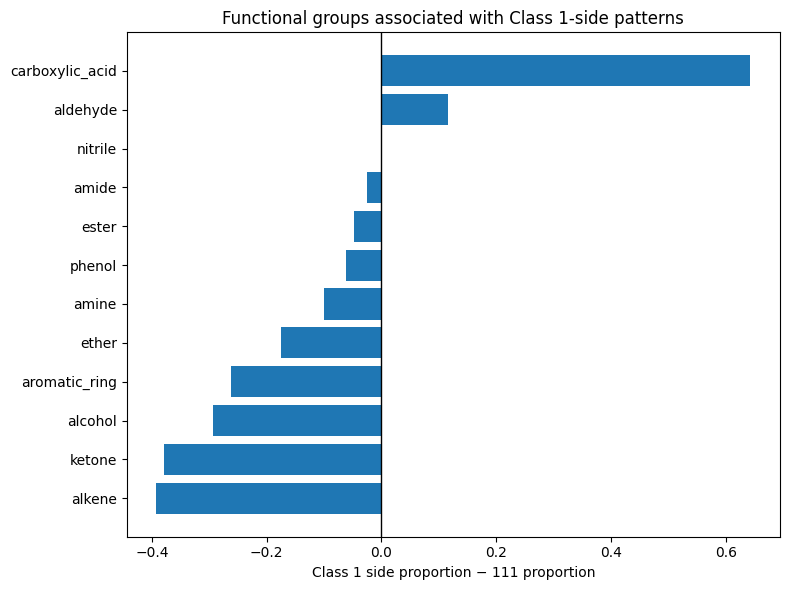

In [55]:
fg_plot = fg_enrich_results.copy()
fg_plot["diff"] = fg_plot["prop_1"] - fg_plot["prop_2"]
fg_plot = fg_plot.sort_values("diff")

plt.figure(figsize=(8, 6))
plt.barh(fg_plot["functional_group"], fg_plot["diff"])
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Class 1 side proportion − 111 proportion")
plt.title("Functional groups associated with Class 1-side patterns")
plt.tight_layout()
plt.show()

### 100+110 VS 011

In [56]:
### are Class 1-associated ligands chemically different from Class 2-associated ligands? ###

pattern_analysis_df["pattern_group3"] = pattern_analysis_df["pattern"].apply(
    lambda p: "class1_side" if p in ["100", "110"]
    else ("class2_side" if p == "011" else "exclude")
)

comp_df = pattern_analysis_df[pattern_analysis_df["pattern_group3"] != "exclude"].copy()

comp_df["pattern_group3"].value_counts()

pattern_group3
class1_side    103
class2_side     86
Name: count, dtype: int64

In [57]:
from scipy.stats import mannwhitneyu

def mw_test(df, value_col, g1="class1_side", g2="class2_side", alternative="two-sided"):
    x = df.loc[df["pattern_group3"] == g1, value_col].dropna().values
    y = df.loc[df["pattern_group3"] == g2, value_col].dropna().values
    stat, p = mannwhitneyu(x, y, alternative=alternative)
    return {
        "descriptor": value_col,
        "n1": len(x),
        "n2": len(y),
        "median1": np.median(x),
        "median2": np.median(y),
        "U_stat": stat,
        "p_value": p
    }

mw_results3 = pd.DataFrame([
    mw_test(comp_df, "logP", alternative="less"),
    mw_test(comp_df, "TPSA", alternative="greater"),
    mw_test(comp_df, "HBD", alternative="greater"),
    mw_test(comp_df, "HBA", alternative="greater"),
    mw_test(comp_df, "MW", alternative="two-sided"),
])

mw_results3

,descriptor,n1,n2,median1,median2,U_stat,p_value
0,logP,103,86,1.8822,2.4017,3115.5,2.274013e-04
1,TPSA,103,86,37.3000,17.0700,7569.5,9.519053e-18
2,HBD,103,86,1.0000,0.0000,7157.0,4.955841e-16
3,HBA,103,86,1.0000,1.0000,5057.5,3.216798e-02
4,MW,103,86,158.2410,150.2210,4534.5,7.791855e-01


In [58]:
from scipy.stats import fisher_exact

fg_cols = [
    "carboxylic_acid", "alcohol", "aldehyde", "ketone", "ester",
    "ether", "amine", "amide", "aromatic_ring", "phenol",
    "nitrile", "alkene"
]

def fisher_fg(df, fg, g1="class1_side", g2="class2_side", alternative="greater"):
    sub1 = df[df["pattern_group3"] == g1]
    sub2 = df[df["pattern_group3"] == g2]

    a = int((sub1[fg] == 1).sum())
    b = int((sub1[fg] == 0).sum())
    c = int((sub2[fg] == 1).sum())
    d = int((sub2[fg] == 0).sum())

    odds_ratio, p = fisher_exact([[a, b], [c, d]], alternative=alternative)

    return {
        "functional_group": fg,
        "present_1": a,
        "total_1": a + b,
        "prop_1": a / (a + b),
        "present_2": c,
        "total_2": c + d,
        "prop_2": c / (c + d),
        "odds_ratio": odds_ratio,
        "p_value": p
    }

fg_results3 = pd.DataFrame([
    fisher_fg(comp_df, fg) for fg in fg_cols
]).sort_values("p_value")

fg_results3

,functional_group,present_1,total_1,prop_1,present_2,total_2,prop_2,odds_ratio,p_value
0,carboxylic_acid,70,103,0.679612,1,86,0.011628,180.303030,6.437300e-25
7,amide,5,103,0.048544,1,86,0.011628,4.336735,1.533199e-01
4,ester,18,103,0.174757,10,86,0.116279,1.609412,1.787315e-01
1,alcohol,8,103,0.077670,5,86,0.058140,1.364211,4.086634e-01
9,phenol,5,103,0.048544,3,86,0.034884,1.411565,4.640678e-01
5,ether,24,103,0.233010,20,86,0.232558,1.002532,5.667210e-01
6,amine,5,103,0.048544,4,86,0.046512,1.045918,6.118431e-01
2,aldehyde,12,103,0.116505,14,86,0.162791,0.678179,8.710512e-01
11,alkene,13,103,0.126214,39,86,0.453488,0.174074,9.999999e-01
3,ketone,3,103,0.029126,26,86,0.302326,0.069231,1.000000e+00


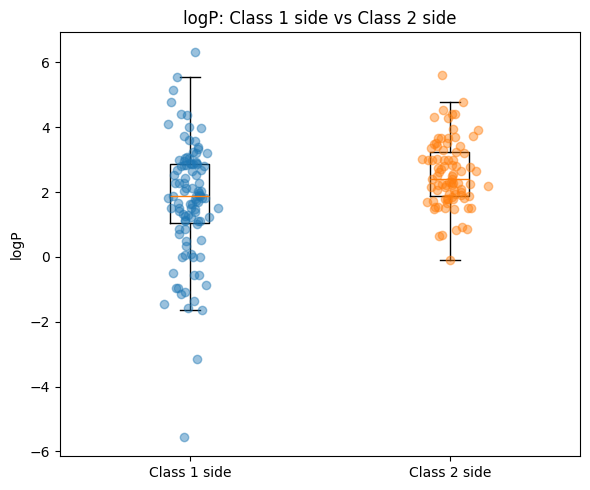

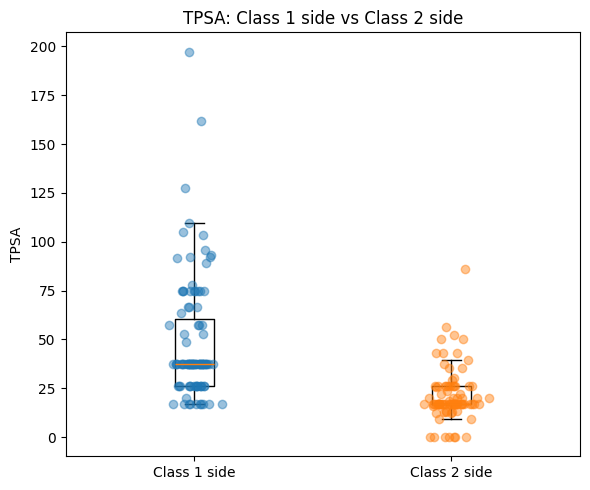

In [59]:
import matplotlib.pyplot as plt

for desc in ["logP", "TPSA"]:
    plt.figure(figsize=(6,5))

    data_to_plot = [
        comp_df.loc[comp_df["pattern_group3"] == g, desc].dropna().values
        for g in ["class1_side", "class2_side"]
    ]

    plt.boxplot(data_to_plot, tick_labels=["Class 1 side", "Class 2 side"], showfliers=False)

    rng = np.random.default_rng(42)
    for i, g in enumerate(["class1_side", "class2_side"], start=1):
        y = comp_df.loc[comp_df["pattern_group3"] == g, desc].dropna().values
        x = rng.normal(i, 0.05, size=len(y))
        plt.plot(x, y, "o", alpha=0.45)

    plt.ylabel(desc)
    plt.title(f"{desc}: Class 1 side vs Class 2 side")
    plt.tight_layout()
    plt.show()

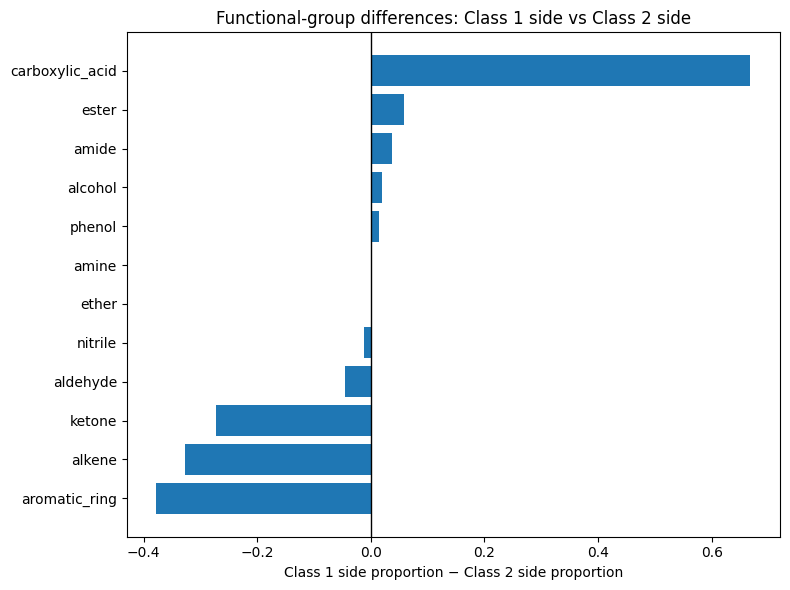

In [60]:
fg_plot3 = fg_results3.copy()
fg_plot3["diff"] = fg_plot3["prop_1"] - fg_plot3["prop_2"]
fg_plot3 = fg_plot3.sort_values("diff")

plt.figure(figsize=(8,6))
plt.barh(fg_plot3["functional_group"], fg_plot3["diff"])
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Class 1 side proportion − Class 2 side proportion")
plt.title("Functional-group differences: Class 1 side vs Class 2 side")
plt.tight_layout()
plt.show()